In [68]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4)

In [ ]:
# Cada archivo BD {año}.xlsx contiene una hoja por estación de monitoreo,
# con mediciones horarias de contaminantes y variables meteorológicas

DATA_DIR = Path("data")
YEARS = range(2020, 2025)

frames = []
for year in YEARS:
    path = DATA_DIR / f"BD {year}.xlsx"
    sheets = pd.read_excel(path, sheet_name=None, engine="openpyxl")
    for estación, sheet_df in sheets.items():
        sheet_df = sheet_df.rename(columns={"Fecha y hora": "fecha_hora", "date": "fecha_hora"})
        sheet_df["estación"] = estación
        sheet_df["año_archivo"] = year
        frames.append(sheet_df)

df = pd.concat(frames, ignore_index=True)
df["estación"] = df["estación"].astype("category")
df = df.sort_values(["estación", "fecha_hora"]).reset_index(drop=True)

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 623,225 | Columnas: 18


,fecha_hora,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,RH,SO2,SR,TOUT,WSR,WDR,estación,año_archivo
0,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CE,2020
1,2020-01-01 01:00:00,3.28,3.3,6.5,9.8,19.0,112.01,85.64,713.6,0.0,91.0,3.3,0.158,10.49,3.7,2.0,CE,2020
2,2020-01-01 02:00:00,3.35,3.1,5.6,8.8,18.0,100.01,72.39,712.8,0.0,91.0,3.0,0.156,10.51,1.9,144.0,CE,2020
3,2020-01-01 03:00:00,3.22,3.2,7.2,10.4,14.0,106.20,70.25,712.4,0.0,92.0,2.9,0.158,10.64,2.7,28.0,CE,2020
4,2020-01-01 04:00:00,3.26,4.7,10.6,15.3,5.0,141.86,93.72,712.0,0.0,92.0,3.3,0.163,10.73,2.0,31.0,CE,2020


# 1) Comprensión de los datos

## 1.1 Dimensión del dataset y descripción de variables

La base combina 5 archivos anuales (2020-2025) de SIMA (Sistema de Monitoreo Atmosférico), cada uno con una hoja de Excel por estación de monitoreo. El número de estaciónes creció de 13 (2020) a 15 (2022-2025), por lo que la serie es un panel **no balanceado** estación×tiempo

| Variable | Descripción | Tipo | Unidad típica* | Rango físico esperado |
|---|---|---|---|---|
| `fecha_hora` | Fecha y hora de la medición (resolución horaria) | Fecha/hora | — | 2020-01-01 a 2024-12-31 |
| `estación` | Clave de la estación de monitoreo (CE, NE, NO, SE, SO, SUR, NTE, y variantes numeradas 2/3 para estaciónes adicionales en la misma zona) | Categórico | — | 13-15 categorías |
| `año_archivo` | Año del archivo fuente (control de trazabilidad, redundante con `fecha_hora`) | Categórico/Numérico | — | 2020-2025 |
| `CO` | Monóxido de carbono | Numérico continuo | ppm | ≥ 0 |
| `NO` | Óxido nítrico | Numérico continuo | ppb | ≥ 0 |
| `NO2` | Dióxido de nitrógeno | Numérico continuo | ppb | ≥ 0 |
| `NOX` | Óxidos de nitrógeno totales (NO + NO2) | Numérico continuo | ppb | ≥ 0, ≥ NO2 |
| `O3` | Ozono | Numérico continuo | ppb | ≥ 0 |
| `PM10` | Partículas suspendidas ≤ 10 micrómetros | Numérico continuo | µg/m³ | ≥ 0 |
| `PM2.5` | Partículas suspendidas ≤ 2.5 micrómetros | Numérico continuo | µg/m³ | ≥ 0, ≤ PM10 |
| `PRS` | Presión barométrica | Numérico continuo | mmHg | > 0 |
| `RAINF` | Precipitación pluvial acumulada en la hora | Numérico continuo | mm | ≥ 0 |
| `RH` | Humedad relativa | Numérico continuo | % | 0-100 |
| `SO2` | Dióxido de azufre | Numérico continuo | ppb | ≥ 0 |
| `SR` | Radiación solar | Numérico continuo | W/m² | ≥ 0 |
| `TOUT` | Temperatura ambiente exterior | Numérico continuo | °C | rango templado |
| `WSR` | Velocidad del viento | Numérico continuo | m/s | ≥ 0 |
| `WDR` | Dirección del viento | Numérico continuo (circular) | grados | 0-360 |

\* Unidades reportadas según el catálogo de parámetros público de SIMA; **conviene confirmarlas contra la documentación oficial de SIMA/SIMAJ** antes de reportarlas en el informe, ya que no vienen especificadas dentro del archivo


In [ ]:
print(f"Dimensión: {df.shape[0]:,} registros x {df.shape[1]} columnas\n")
df.info()

Dimensión: 623,225 registros x 18 columnas

<class 'pandas.DataFrame'>
RangeIndex: 623225 entries, 0 to 623224
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   fecha_hora   623225 non-null  datetime64[us]
 1   CO           540567 non-null  float64       
 2   NO           516344 non-null  float64       
 3   NO2          509519 non-null  float64       
 4   NOX          513877 non-null  float64       
 5   O3           520720 non-null  float64       
 6   PM10         594649 non-null  float64       
 7   PM2.5        477669 non-null  float64       
 8   PRS          591918 non-null  float64       
 9   RAINF        593420 non-null  float64       
 10  RH           561174 non-null  float64       
 11  SO2          522255 non-null  float64       
 12  SR           601729 non-null  float64       
 13  TOUT         586336 non-null  float64       
 14  WSR          576049 non-null  float64       
 15  W

In [ ]:
# Cobertura por estación y por año
cobertura = (
    df.assign(año=df["fecha_hora"].dt.year)
    .groupby(["estación", "año"], observed=True)
    .size()
    .unstack(fill_value=0)
)
cobertura

año,2020,2021,2022,2023,2024
estación,,,,,
CE,8784,8760,8760,8758,8784
NE,8776,8759,8760,8758,8784
NE2,8776,8759,8760,8758,8782
NE3,0,8759,8760,8757,8782
NO,8778,8759,8760,8758,8783
NO2,8776,8759,8760,8759,8782
NO3,0,0,743,8759,8784
NTE,8777,8759,8760,8758,8782
NTE2,8776,8759,8760,8758,8782


## 1.2 Calidad de los datos: valores faltantes, duplicados y valores espurios

In [72]:
# Valores faltantes por variable
faltantes = df.isna().sum().to_frame("n_faltantes")
faltantes["pct_faltantes"] = (faltantes["n_faltantes"] / len(df) * 100).round(2)
faltantes.sort_values("pct_faltantes", ascending=False)

,n_faltantes,pct_faltantes
PM2.5,145556,23.36
NO2,113706,18.24
NOX,109348,17.55
NO,106881,17.15
O3,102505,16.45
SO2,100970,16.20
CO,82658,13.26
RH,62051,9.96
WDR,58717,9.42
WSR,47176,7.57


In [ ]:
# Faltantes por estación
faltantes_por_estación = (
    df.groupby("estación", observed=True)
    .apply(lambda g: g.isna().mean() * 100)
    .round(1)
)
faltantes_por_estación

,fecha_hora,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,RH,SO2,SR,TOUT,WSR,WDR,año_archivo
estación,,,,,,,,,,,,,,,,,
CE,0.0,3.0,8.6,7.3,7.6,8.1,3.0,14.2,2.0,1.9,2.3,5.2,1.5,1.9,2.0,2.0,0.0
NE,0.0,11.8,15.4,24.1,24.1,25.7,3.4,7.3,5.5,4.5,6.0,24.6,2.8,13.7,15.3,8.8,0.0
NE2,0.0,13.3,24.9,24.9,24.0,25.2,5.2,20.2,2.8,2.5,4.0,13.0,0.8,2.5,15.2,10.2,0.0
NE3,0.0,4.6,5.8,5.8,5.9,4.7,5.7,100.0,4.7,3.7,3.8,34.0,11.9,4.3,6.5,3.8,0.0
NO,0.0,31.1,21.6,26.8,26.0,28.4,6.3,35.6,3.2,2.7,12.5,20.1,2.4,12.4,6.4,12.1,0.0
NO2,0.0,2.6,5.6,10.9,5.3,7.0,2.8,14.6,4.4,1.9,5.2,12.2,19.7,2.7,4.5,8.3,0.0
NO3,0.0,13.8,14.6,14.5,14.5,9.8,5.2,87.2,0.8,0.8,43.1,7.9,1.0,0.8,11.2,1.9,0.0
NTE,0.0,26.9,29.1,28.8,28.9,26.8,9.5,16.3,24.7,20.2,50.3,29.4,7.2,23.4,21.4,24.3,0.0
NTE2,0.0,6.2,20.0,21.0,21.0,22.8,3.7,15.3,1.2,1.1,1.4,28.8,0.5,1.2,1.1,1.2,0.0


In [74]:
# Duplicados: filas 100% idénticas y duplicados de llave (misma estación + misma hora)
dup_totales = df.duplicated().sum()
dup_llave = df.duplicated(subset=["estación", "fecha_hora"]).sum()
print(f"Filas totalmente duplicadas: {dup_totales:,}")
print(f"Duplicados de llave (estación, fecha_hora): {dup_llave:,}")

Filas totalmente duplicadas: 0
Duplicados de llave (estación, fecha_hora): 0


In [75]:
# Estadísticos descriptivos: revisamos mínimos/máximos para detectar valores físicamente imposibles
contaminantes = ["CO", "NO", "NO2", "NOX", "O3", "PM10", "PM2.5", "SO2"]
meteo = ["PRS", "RAINF", "RH", "SR", "TOUT", "WSR", "WDR"]
numericas = contaminantes + meteo

df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
CO,540567.0,1.403402,0.876103,0.0,0.74,1.260,1.890,37.0
NO,516344.0,12.232813,22.378083,0.3,3.00,5.100,11.300,945.1
NO2,509519.0,14.518916,11.450686,0.0,6.60,11.300,19.400,188.6
NOX,513877.0,26.563703,28.974710,0.5,10.80,17.500,31.100,971.8
O3,520720.0,26.818983,18.660389,0.7,13.00,23.000,37.000,265.0
PM10,594649.0,59.399979,40.688751,1.0,35.00,50.760,73.000,1001.0
PM2.5,477669.0,20.698086,15.644999,0.0,10.68,17.000,27.000,999.0
SO2,522255.0,4.908861,4.531039,0.0,2.80,3.800,5.500,295.1
PRS,591918.0,715.204056,9.536476,0.0,709.50,714.300,721.600,747.6
RAINF,593420.0,0.020519,1.102208,0.0,0.00,0.000,0.000,360.0


In [ ]:
# Conteo de valores erróneos según límites físicos conocidos
reglas_espurios = {
    "Concentraciones negativas (contaminantes < 0)": (df[contaminantes] < 0).sum().sum(),
    "RH fuera de [0, 100]%": (~df["RH"].between(0, 100) & df["RH"].notna()).sum(),
    "WDR fuera de [0, 360] grados": (~df["WDR"].between(0, 360) & df["WDR"].notna()).sum(),
    "RAINF negativa": (df["RAINF"] < 0).sum(),
    "WSR negativa": (df["WSR"] < 0).sum(),
    "PM2.5 > PM10 (inconsistencia física)": (df["PM2.5"] > df["PM10"]).sum(),
    "NO2 > NOX (inconsistencia física)": (df["NO2"] > df["NOX"]).sum(),
}
pd.Series(reglas_espurios, name="n_registros_afectados").to_frame()

,n_registros_afectados
Concentraciones negativas (contaminantes < 0),0
"RH fuera de [0, 100]%",278
"WDR fuera de [0, 360] grados",0
RAINF negativa,0
WSR negativa,0
PM2.5 > PM10 (inconsistencia física),31
NO2 > NOX (inconsistencia física),630


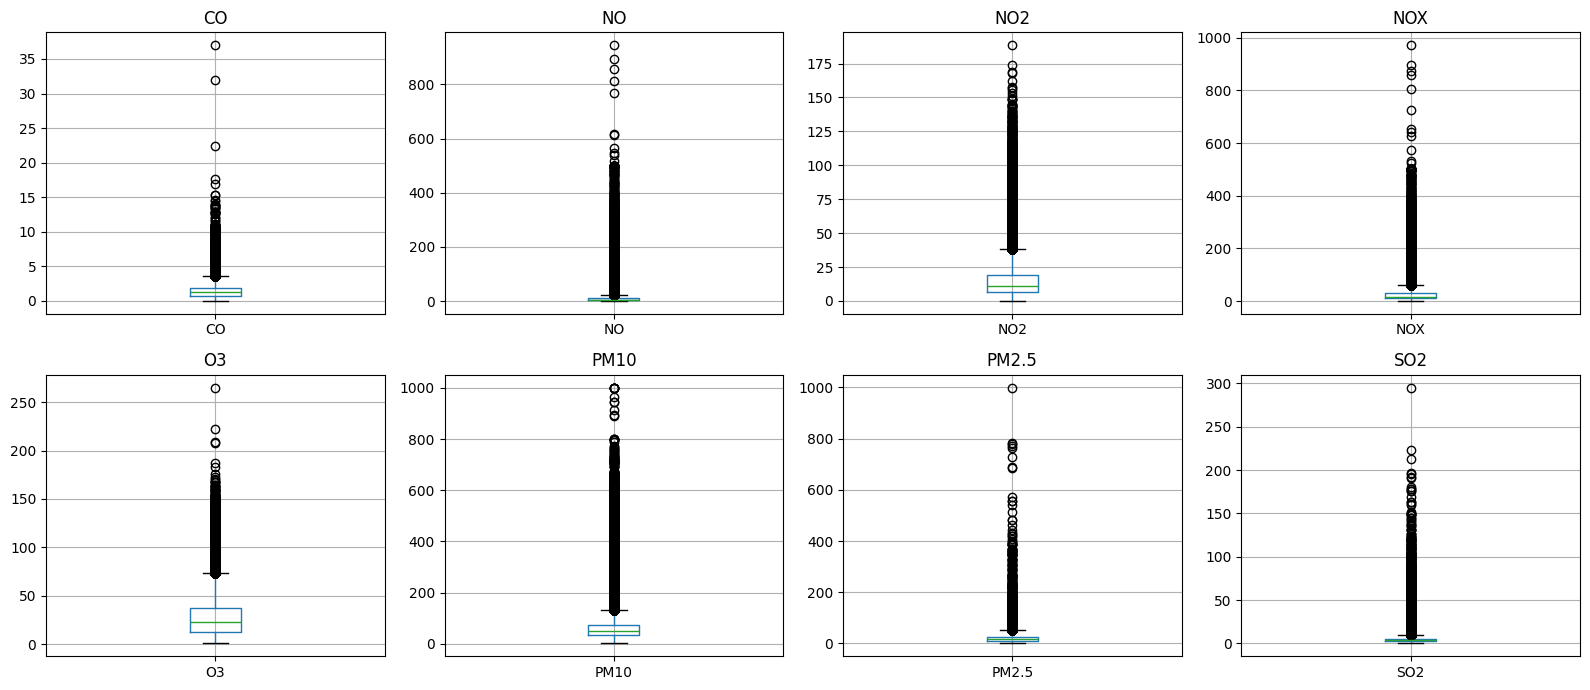

In [ ]:
# Visualización de dispersión/outliers por contaminante
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, contaminantes):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# 2) Preparación de los datos

## 2.1 Selección del conjunto de datos

- **Incluimos** los 5 años completos 2020-2024 y todas las estaciónes reportadas en cada año, para preservar la mayor cobertura espacial y temporal posible y permitir comparaciones entre zonas de la ciudad.
- **Excluimos** por ahora `BD 2025.xlsx` (ya presente en `data/`), porque es un año incompleto (~6 meses) y mezclar un año parcial con años completos sesgaría cualquier comparación anual o estaciónal.
- `año_archivo` se conserva solo como control de trazabilidad (para detectar si un archivo fue mal etiquetado); el análisis temporal real debe basarse en `fecha_hora`.

## 2.2 Columnas objetivo

> **Posibles objetivos de indagación** 
> -  **salud pública**: `PM2.5` u `O3` (contaminantes más asociados a efectos respiratorios/cardiovasculares)
> -  **pronóstico**: la variable meteorológica/contaminante a predecir a t+1
> - **comparación espacial**: `estación` como variable de agrupación, no como target numérico


## 2.3 Limpieza de datos

In [ ]:
# Duplicados
df_clean = df.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset=["estación", "fecha_hora"], keep="first").copy()
print(f"Filas antes: {len(df):,} | después de quitar duplicados: {len(df_clean):,}")

Filas antes: 623,225 | después de quitar duplicados: 623,225


In [ ]:
# Valores erróneos
# Criterio: los valores físicamente imposibles se tratan como NaN (no se inventan, se marcan
# como faltantes y se manejan en el siguiente paso). Esto es distinto de un outlier extremo
# pero físicamente posible (p. ej. un pico real de PM2.5 por incendio), que NO se toca aquí

for col in contaminantes:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

df_clean.loc[~df_clean["RH"].between(0, 100), "RH"] = np.nan
df_clean.loc[~df_clean["WDR"].between(0, 360), "WDR"] = np.nan
df_clean.loc[df_clean["RAINF"] < 0, "RAINF"] = np.nan
df_clean.loc[df_clean["WSR"] < 0, "WSR"] = np.nan

print("Valores erróneos corregidos (convertidos a NaN):")
for regla, n in reglas_espurios.items():
    print(f"  - {regla}: {n:,}")

Valores erróneos corregidos (convertidos a NaN):
  - Concentraciones negativas (contaminantes < 0): 0
  - RH fuera de [0, 100]%: 278
  - WDR fuera de [0, 360] grados: 0
  - RAINF negativa: 0
  - WSR negativa: 0
  - PM2.5 > PM10 (inconsistencia física): 31
  - NO2 > NOX (inconsistencia física): 630


In [ ]:
# Valores faltantes
# Al ser series de tiempo por estación, interpolamos SOLO huecos cortos (<=3 horas), que
# suelen deberse a fallas puntuales de transmisión del sensor. Huecos largos (mantenimiento,
# sensor caído varios días) se dejan como NaN: rellenarlos inventaría información que no
# tenemos, y para muchos análisis (promedios, KPIs regulatorios) es mejor excluir el hueco
# que sesgarlo con datos interpolados poco confiables
df_clean = df_clean.sort_values(["estación", "fecha_hora"])

MAX_HUECO_HORAS = 3
for col in numericas:
    df_clean[col] = df_clean.groupby("estación", observed=True)[col].transform(
        lambda s: s.interpolate(method="linear", limit=MAX_HUECO_HORAS, limit_direction="both")
    )

pct_tras_interpolar = (df_clean[numericas].isna().mean() * 100).round(2)
pct_tras_interpolar.to_frame("pct_faltantes_tras_interpolar")

,pct_faltantes_tras_interpolar
CO,11.93
NO,13.66
NO2,15.72
NOX,15.04
O3,13.88
PM10,2.70
PM2.5,17.85
SO2,11.54
PRS,3.80
RAINF,3.86


## 2.4 Datos categóricos

La única variable categórica real es `estación` (13-15 niveles). No convertimos a variables *dummy* de forma automática porque:
- Para análisis exploratorio, series de tiempo y modelos basados en árboles (Random Forest, XGBoost), `estación` puede usarse directamente como categoría — no necesita one-hot encoding
- Las *dummies* (one-hot) son necesarias si más adelante se ajusta un modelo **lineal** (regresión lineal/logística) que requiera variables puramente numéricas, o si se quiere usar `estación` como efecto fijo en un modelo de regresión

Dejamos el encoding como paso condicional, a aplicar solo si el modelo elegido en la Parte I lo requiere:

In [ ]:
#  one-hot encoding de estación, solo si el modelo lo requiere
df_dummies_ejemplo = pd.get_dummies(df_clean["estación"], prefix="estación")
df_dummies_ejemplo.head()

,estación_CE,estación_NE,estación_NE2,estación_NE3,estación_NO,estación_NO2,estación_NO3,estación_NTE,estación_NTE2,estación_SE,estación_SE2,estación_SE3,estación_SO,estación_SO2,estación_SUR
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 2.5 Valores atípicos (outliers)

Importante: en datos de contaminación, un valor extremo (p. ej. PM2.5 muy alto por incendios forestales, quema agrícola, o una inversión térmica) puede ser un **evento real y relevante**, no un error. Por eso no eliminamos outliers automáticamente: los **detectamos y marcamos** con una bandera booleana por variable (método IQR, calculado por estación para respetar las diferencias entre zonas).

In [82]:
def marcar_outliers_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - k * iqr, q3 + k * iqr
    return ~s.between(lim_inf, lim_sup) & s.notna()

for col in contaminantes:
    df_clean[f"{col}_outlier"] = df_clean.groupby("estación", observed=True)[col].transform(marcar_outliers_iqr)

outlier_cols = [f"{col}_outlier" for col in contaminantes]
print("% de registros marcados como outlier por variable (dentro de su estación):")
(df_clean[outlier_cols].mean() * 100).round(2)

% de registros marcados como outlier por variable (dentro de su estación):


CO_outlier        1.47
NO_outlier       10.19
NO2_outlier       3.77
NOX_outlier       6.93
O3_outlier        2.02
PM10_outlier      4.60
PM2.5_outlier     2.92
SO2_outlier       6.81
dtype: float64

# 3) Transformación de datos

## 3.1 Atributos derivados

A partir de `fecha_hora` construimos atributos de calendario que casi cualquier análisis de calidad del aire necesita, porque la contaminación tiene fuertes patrones horarios (tráfico), semanales (entre semana vs. fin de semana) y estaciónales (temporada seca vs. lluvias)

In [ ]:
df_clean["año"] = df_clean["fecha_hora"].dt.year
df_clean["mes"] = df_clean["fecha_hora"].dt.month
df_clean["hora"] = df_clean["fecha_hora"].dt.hour
df_clean["dia_semana"] = df_clean["fecha_hora"].dt.dayofweek  # 0 = lunes
df_clean["es_fin_de_semana"] = df_clean["dia_semana"] >= 5


def temporada_s(mes):
    # Clasificación climática
    if mes in (11, 12, 1, 2):
        return "seca-fria"
    elif mes in (3, 4, 5):
        return "seca-calida"
    else:
        return "lluvias"


df_clean["temporada"] = df_clean["mes"].apply(temporada_s).astype("category")
df_clean[["fecha_hora", "año", "mes", "hora", "dia_semana", "es_fin_de_semana", "temporada"]].head()

,fecha_hora,año,mes,hora,dia_semana,es_fin_de_semana,temporada
0,2020-01-01 00:00:00,2020,1,0,2,False,seca-fria
1,2020-01-01 01:00:00,2020,1,1,2,False,seca-fria
2,2020-01-01 02:00:00,2020,1,2,2,False,seca-fria
3,2020-01-01 03:00:00,2020,1,3,2,False,seca-fria
4,2020-01-01 04:00:00,2020,1,4,2,False,seca-fria


## 3.2 Discretización (binning)

México clasifica la calidad del aire con el índice IMECA/AICA, que tiene umbrales oficiales específicos por contaminante (definidos en las NOM correspondientes, p. ej. NOM-020-SSA1 para O3 y PM2.5, NOM-025-SSA1 para PM10). **No hardcodeamos esos umbrales aquí** porque deben tomarse de la norma oficial vigente (parte de la investigación bibliográfica de la Parte I), no inventarse. Mientras tanto, mostramos una discretización **ilustrativa** por cuartiles, solo para ver cómo se vería una variable categórica derivada de una continua — debe sustituirse por los cortes oficiales del IMECA una vez confirmados

In [ ]:
# cortes oficiales del IMECA/NOM 
df_clean["PM2.5_nivel_cuartil"] = pd.qcut(
    df_clean["PM2.5"], q=4, labels=["bajo", "medio", "alto", "muy_alto"]
)
df_clean["PM2.5_nivel_cuartil"].value_counts()

PM2.5_nivel_cuartil
medio       135797
bajo        128049
muy_alto    127989
alto        120124
Name: count, dtype: int64

## 3.3 Escalamiento y normalización

Las variables están en escalas muy distintas (CO en ppm ~0-5, PM10 en µg/m³ ~0-300, WDR en grados 0-360). Esto **no hace falta** para reportes descriptivos, series de tiempo o modelos de árboles, pero **sí es necesario** si más adelante se usa un modelo sensible a la escala (regresión con regularización, KNN, redes neuronales, PCA, clustering). Guardamos una versión escalada aparte (`df_scaled`), sin sobreescribir los valores originales interpretables

In [85]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_clean.copy()
scaler = StandardScaler()
df_scaled[numericas] = scaler.fit_transform(df_clean[numericas])
df_scaled[numericas].describe().T[["mean", "std"]]

,mean,std
CO,-1.988387e-17,1.000001
NO,-5.070759e-18,1.000001
NO2,-1.038955e-16,1.000001
NOX,-6.785018e-17,1.000001
O3,-1.575839e-16,1.000001
PM10,-2.759826e-16,1.000001
PM2.5,-7.461296e-17,1.000001
SO2,1.418820e-16,1.000001
PRS,5.667607e-15,1.000001
RAINF,7.589824e-19,1.000001


# 4) Reestructuración de los datos

El formato actual de `df_clean` ya es **long/tidy**: cada fila es una observación (una estación, una hora), cada columna una variable. Este formato es el más flexible para explorar, filtrar y modelar. La única reestructuración adicional depende de cómo se vaya a usar la información:

- Para comparar estaciónes lado a lado en el tiempo → `pivot` a formato ancho, una columna por estación (útil para gráficas de series de tiempo superpuestas)
- Para agregación diaria/mensual (p. ej. promedios regulatorios) → `groupby` de `estación` + fecha truncada a día/mes

Se muestran ambos como ejemplos, sin sobreescribir `df_clean`:

In [86]:
# PM2.5 por estación en columnas
pm25_ancho = df_clean.pivot_table(index="fecha_hora", columns="estación", values="PM2.5", observed=True)
pm25_ancho.head()

estación,CE,NE,NE2,NO,NO2,NO3,NTE,NTE2,SE,SE2,SE3,SO,SO2,SUR
fecha_hora,,,,,,,,,,,,,,
2020-01-01 00:00:00,85.64,107.550,22.000000,70.81,86.930,NaN,49.71,62.0,54.230,NaN,18.0,59.26,37.0,11.0
2020-01-01 01:00:00,85.64,76.055,17.666667,76.73,79.430,NaN,46.70,54.0,54.035,NaN,28.0,51.43,37.0,11.0
2020-01-01 02:00:00,72.39,44.560,13.333333,82.65,71.930,NaN,44.42,46.0,53.840,NaN,28.0,50.88,42.0,21.0
2020-01-01 03:00:00,70.25,43.665,9.000000,51.16,64.910,NaN,46.84,38.0,36.470,NaN,11.0,47.99,36.0,31.0
2020-01-01 04:00:00,93.72,42.770,8.500000,56.29,67.362,NaN,33.15,25.0,33.590,NaN,10.0,49.90,47.0,12.0


In [87]:
# promedio diario por estación (agregación típica para reportes regulatorios)
promedio_diario = (
    df_clean.groupby(["estación", df_clean["fecha_hora"].dt.date], observed=True)[numericas]
    .mean()
    .reset_index()
    .rename(columns={"fecha_hora": "fecha"})
)
promedio_diario.head()

,estación,fecha,CO,NO,NO2,NOX,O3,PM10,PM2.5,SO2,PRS,RAINF,RH,SR,TOUT,WSR,WDR
0,CE,2020-01-01,3.157500,4.120833,6.650000,10.775000,15.625000,66.160417,41.560417,2.716667,711.254167,0.0,89.125000,0.159917,12.279583,2.466667,189.958333
1,CE,2020-01-02,3.245000,8.412500,9.229167,17.637500,19.166667,37.528750,9.342083,2.879167,705.408333,0.0,62.083333,0.168708,16.812917,3.762500,201.500000
2,CE,2020-01-03,2.916250,4.558333,6.325000,10.883333,32.791667,37.939583,8.061667,3.637500,711.533333,0.0,35.291667,0.166542,17.174583,9.875000,260.666667
3,CE,2020-01-04,3.024583,5.670833,9.579167,15.245833,25.750000,47.499583,16.165833,3.916667,719.620833,0.0,39.166667,0.172625,14.604583,3.679167,179.958333
4,CE,2020-01-05,3.157500,5.025000,12.058333,17.033333,25.854167,62.838333,27.457500,7.495833,718.254167,0.0,40.083333,0.175208,15.855417,3.662500,183.125000


In [88]:
# Guardamos la base limpia
Path("output").mkdir(exist_ok=True)
df_clean.to_parquet("output/sima_2020_2024_limpio.parquet", index=False)
print(f"Guardado: output/sima_2020_2024_limpio.parquet ({len(df_clean):,} filas)")

Guardado: output/sima_2020_2024_limpio.parquet (623,225 filas)


# 5) Exploración para definir el objetivo de indagación

Ahora, exploramos patrones visibles en los datos: tendencia a lo largo de los años, patrón horario (tráfico vs. fotoquímica), diferencias entre estaciónes, y relación con variables meteorológicas. Cualquiera de estos patrones puede convertirse en la pregunta de investigación del proyecto

## 5.1 Tendencia anual (promedio de la ciudad, todas las estaciónes)

¿La calidad del aire ha mejorado o empeorado en 2020-2024? 2020 incluye el confinamiento por COVID-19 (menos tráfico), interesante como quiebre natural en la serie

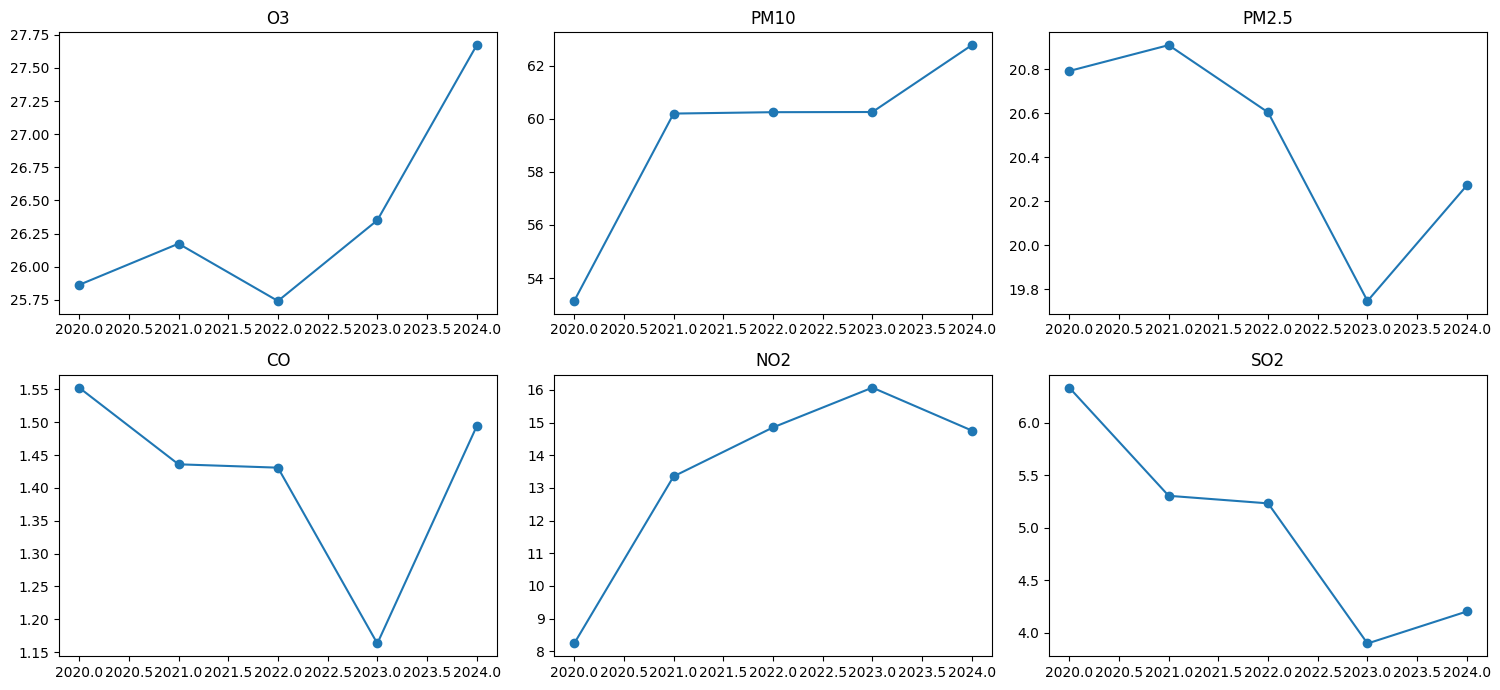

,O3,PM10,PM2.5,CO,NO2,SO2
año,,,,,,
2020,25.862553,53.135694,20.791324,1.552630,8.238097,6.335487
2021,26.173404,60.197282,20.908789,1.435916,13.353260,5.304390
2022,25.741012,60.249359,20.603403,1.430807,14.852199,5.232243
2023,26.350242,60.256047,19.746453,1.163195,16.070400,3.896518
2024,27.671904,62.776038,20.271769,1.493963,14.756595,4.201889


In [96]:
tendencia_anual = df_clean.groupby("año")[["O3", "PM10", "PM2.5", "CO", "NO2", "SO2"]].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, tendencia_anual.columns):
    tendencia_anual[col].plot(ax=ax, marker="o")
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

tendencia_anual

## 5.2 Patrón horario: ¿tráfico (NO2/CO) vs. fotoquímica (O3)?

Los contaminantes primarios (NO2, CO) suelen tener picos en horas de tráfico (mañana/tarde), mientras que el O3 se forma por reacción fotoquímica y su pico es al mediodía/tarde, con retraso respecto a sus precursores. Ver esto en los datos ayuda a decidir si el proyecto se orienta a tráfico vehicular

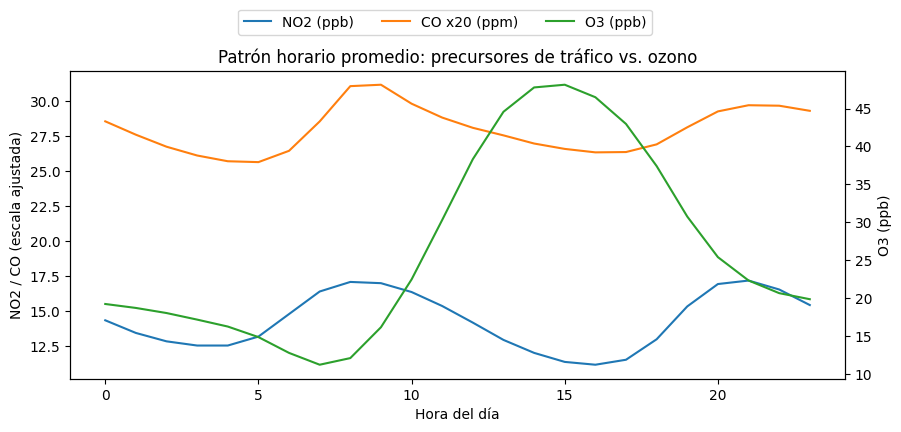

In [97]:
patron_horario = df_clean.groupby("hora")[["NO2", "CO", "O3"]].mean()

fig, ax1 = plt.subplots()
ax1.plot(patron_horario.index, patron_horario["NO2"], color="tab:blue", label="NO2 (ppb)")
ax1.plot(patron_horario.index, patron_horario["CO"] * 20, color="tab:orange", label="CO x20 (ppm)")
ax1.set_xlabel("Hora del día")
ax1.set_ylabel("NO2 / CO (escala ajustada)")
ax2 = ax1.twinx()
ax2.plot(patron_horario.index, patron_horario["O3"], color="tab:green", label="O3 (ppb)")
ax2.set_ylabel("O3 (ppb)")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.title("Patrón horario promedio: precursores de tráfico vs. ozono")
plt.show()

## 5.3 Entre semana vs. fin de semana

Si los contaminantes de tráfico bajan claramente el fin de semana, es evidencia de que el tráfico vehicular es una fuente dominante — un ángulo de proyecto posible (p. ej. política de "Hoy No Circula" o transporte)

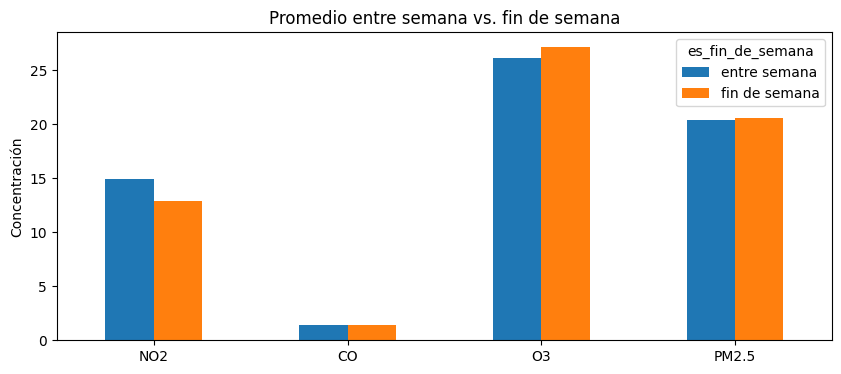

,NO2,CO,O3,PM2.5
es_fin_de_semana,,,,
entre semana,14.903921,1.403225,26.166853,20.417207
fin de semana,12.899260,1.387607,27.161171,20.577954


In [98]:
semana_vs_finde = df_clean.groupby("es_fin_de_semana")[["NO2", "CO", "O3", "PM2.5"]].mean()
semana_vs_finde.index = semana_vs_finde.index.map({False: "entre semana", True: "fin de semana"})
semana_vs_finde.T.plot(kind="bar")
plt.title("Promedio entre semana vs. fin de semana")
plt.ylabel("Concentración")
plt.xticks(rotation=0)
plt.show()

semana_vs_finde

## 5.4 Diferencia entre temporadas (seca-fría, seca-cálida, lluvias)

La lluvia limpia partículas del aire, mientras que la inversión térmica en temporada seca-fría suele atrapar contaminantes cerca del suelo. Ver esta diferencia sugiere un proyecto centrado en meteorología y dispersión de contaminantes

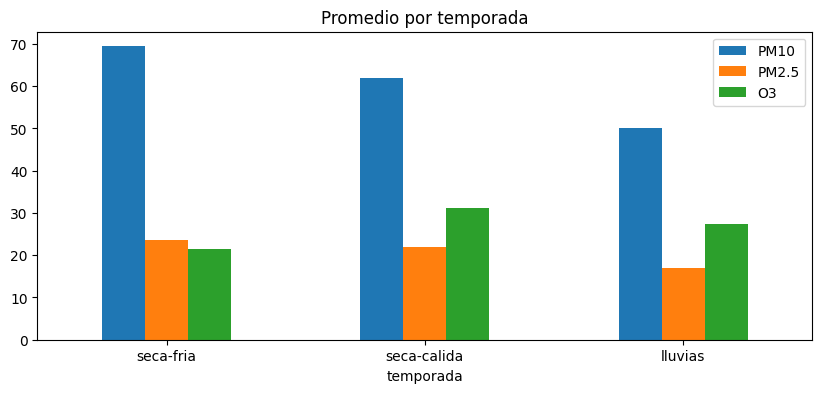

,PM10,PM2.5,O3
temporada,,,
seca-fria,69.423016,23.524041,21.382410
seca-calida,61.971737,22.049806,31.213712
lluvias,50.074345,17.073729,27.365580


In [99]:
temporada_orden = ["seca-fria", "seca-calida", "lluvias"]
por_temporada = df_clean.groupby("temporada", observed=True)[["PM10", "PM2.5", "O3"]].mean().reindex(temporada_orden)
por_temporada.plot(kind="bar")
plt.title("Promedio por temporada")
plt.xticks(rotation=0)
plt.show()

por_temporada

## 5.5 Comparación espacial entre estaciónes

¿Hay zonas de la ciudad consistentemente más contaminadas que otras? Esto sugiere un proyecto de **justicia ambiental** (¿qué zonas/poblaciones están más expuestas?) o de identificación de fuentes locales (industria, vialidades)

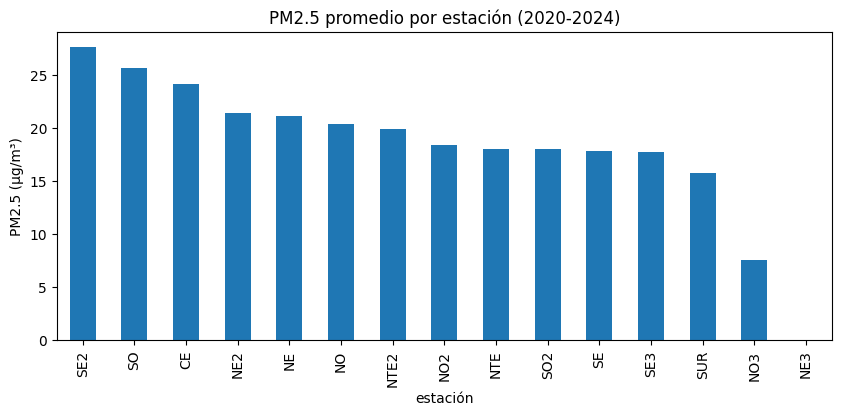

estación
SE2     27.632919
SO      25.622037
CE      24.144875
NE2     21.422089
NE      21.175181
NO      20.353287
NTE2    19.944465
NO2     18.384906
NTE     18.026577
SO2     17.980318
SE      17.807725
SE3     17.717844
SUR     15.747435
NO3      7.556900
NE3           NaN
Name: PM2.5, dtype: float64

In [100]:
por_estación = df_clean.groupby("estación", observed=True)["PM2.5"].mean().sort_values(ascending=False)
por_estación.plot(kind="bar", figsize=(10, 4))
plt.title("PM2.5 promedio por estación (2020-2024)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

por_estación

## 5.6 Correlación entre contaminantes y variables meteorológicas

Si un contaminante correlaciona fuertemente con temperatura, viento o humedad, eso sugiere un proyecto de **pronóstico** (predecir el contaminante a partir del clima) o de **dispersión atmosférica**

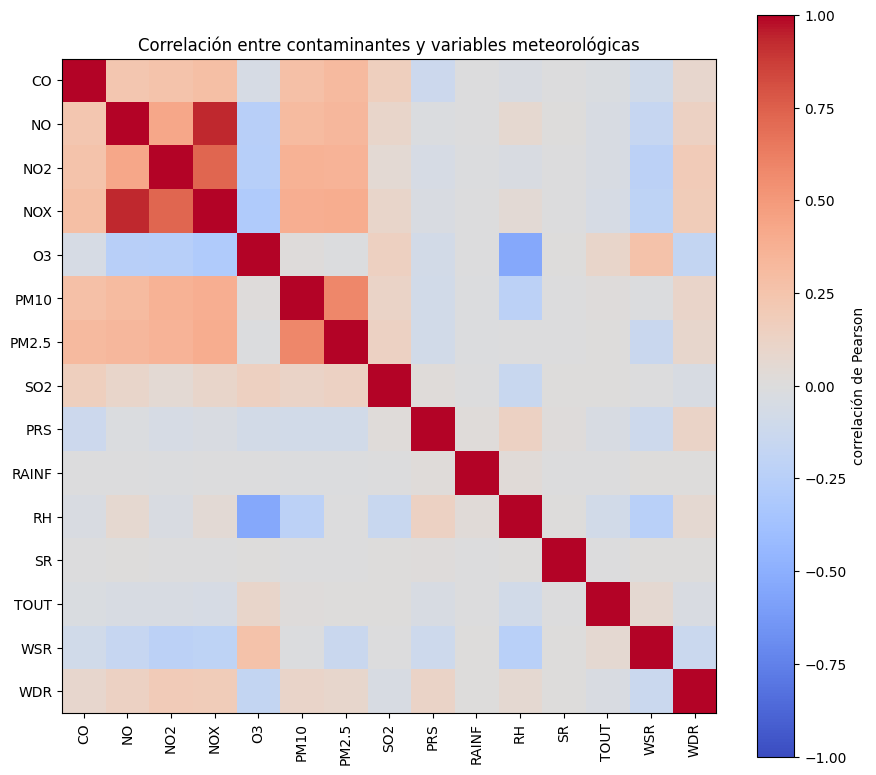

In [101]:
corr = df_clean[numericas].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numericas)))
ax.set_xticklabels(numericas, rotation=90)
ax.set_yticks(range(len(numericas)))
ax.set_yticklabels(numericas)
fig.colorbar(im, label="correlación de Pearson")
plt.title("Correlación entre contaminantes y variables meteorológicas")
plt.tight_layout()
plt.show()

## 5.7 Cómo usar esta exploración para elegir el objetivo

Tendencia anual (5.1). Lo que más llama la atención es el NO2: pasa de 8.24 ppb en 2020 a 13.35 en 2021, y ya no baja de ahí en todo 2022-2024. Justo coincide con el fin del confinamiento por COVID, cuando volvió el tráfico. El PM10 también sube con los años (53.1 → 62.8 µg/m³), pero ahí hay que tener cuidado antes de decir "el aire empeoró": entre 2020 y 2024 se agregaron 2 estaciones nuevas, así que parte de esa subida puede ser porque ahora se está midiendo en más puntos de la ciudad, no necesariamente porque haya más contaminación en general. El O3 se queda bastante parejo (25.9 a 27.7) y el SO2 y el CO más bien bajan un poco.

Patrón por hora (5.2). Aquí sí se ve clarísimo el efecto del tráfico. El NO2 tiene dos picos: uno como a las 8am (17.1 ppb) y otro como a las 9pm (17.2 ppb), justo las horas pico. El CO hace algo parecido, con su punto más alto a las 9am. El O3 va al revés: está en su mínimo justo cuando el tráfico está en su pico de la mañana (11.2 ppb a las 7am) y no llega a su máximo hasta las 3pm (48.1 ppb). Tiene sentido: el ozono no sale directo del escape de los coches, se forma horas después por la reacción de esos gases con el sol.

Entre semana vs. fin de semana (5.3). El NO2 baja de 14.9 a 12.9 ppb el fin de semana (como 13% menos), lo que otra vez apunta al tráfico como fuente. Lo curioso es que el O3 sube un poco el fin de semana (26.2 → 27.2): con menos NOx fresco en el aire hay menos "consumo" de ozono cerca de las fuentes — esto es un efecto que ya está documentado en otros estudios como el "weekend effect" del ozono.

Por temporada (5.4). PM10 y PM2.5 son notablemente más altos en temporada seca-fría (69.4 y 23.5) que en lluvias (50.1 y 17.1): la lluvia lava las partículas y en época seca-fría las inversiones térmicas las atrapan cerca del suelo. El O3, en cambio, es más alto en seca-cálida (31.2), cuando hay más radiación solar para la reacción fotoquímica.

Por estación (5.5). Las diferencias entre zonas son grandes: SE2 tiene el PM2.5 promedio más alto (27.6 µg/m³) y SUR el más bajo entre las estaciones con datos confiables (15.7) — casi el doble. (NO3 y NE3 casi no traen datos porque son estaciones que empezaron a operar después, así que por ahora no son muy comparables con el resto).

Correlaciones (5.6). Lo que más se relaciona con el O3 es la humedad relativa, pero en negativo (-0.54): entre menos húmedo, más ozono. También correlaciona en negativo con NO2 y NOX (-0.25 a -0.29). El PM2.5 se relaciona sobre todo con PM10 (0.58, es casi obvio) y después con los gases de combustión NOx/NO2/CO (0.32-0.40), lo que sugiere que comparten fuente: quema de combustible.

Conclusión. La señal más fuerte y consistente en todos lados es la del tráfico vehicular: se ve en el salto de NO2 post-COVID, en los dos picos horarios de NO2/CO, en la caída de fin de semana, y en que PM2.5 correlaciona más con los gases de combustión que con cualquier variable meteorológica. La comparación entre estaciones (5.5) también da para un ángulo interesante de exposición desigual por zona, pero con menos "historia" detrás que explique el por qué. Por eso me voy a ir por el objetivo de tráfico vehicular como fuente de contaminación y su relación con la exposición ciudadana, usando NO2 y PM2.5 como las variables objetivo principales.

## ETAPA 2: Conociendo los datos